### Performing Exploratory Data Analysis in an Obfuscated Dataset using Principal Component Analysis and t-SNE.

##### Name: Ananya Agrawal
##### Andrew ID: ananyaa2

##### 38615: Computational Modelling, Statistical Analysis and Machine Learning in Science - Homework 1


#### add import statements

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

**1. Loading data, preparing for analysis and processing**

In [ ]:
!wget "https://raw.githubusercontent.com/ananya0809/EDA_PCA_ML/main/hw1_dataset.csv"

--2024-09-15 15:48:30--  https://raw.githubusercontent.com/ananya0809/EDA_PCA_ML/main/hw1_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14862239 (14M) [text/plain]
Saving to: ‘hw1_dataset.csv.2’

hw1_dataset.csv.2   100%[===================>]  14.17M  --.-KB/s    in 0.1s    

2024-09-15 15:48:31 (147 MB/s) - ‘hw1_dataset.csv.2’ saved [14862239/14862239]



In [ ]:
dataset = pd.read_csv("hw1_dataset.csv")
dataset

,experimental_proprty,MS_enc,nHetero,nX,C2SP3,MPC5,ATS0i,NaasN,SsCH3,nCl,...,AATS0Z,ATSC0are,ATSC2pe,SsCl,ATS6v,AATSC1dv,nFARing,AATS2v,Xp-7dv,n6Ring
0,3.54,PPENPINEAPLE42,5,1,0,83,7305.483137,1,2.105782,1,...,26.444444,2.995920,-0.508149,5.976320,16177.071020,1.102539,0,223.767000,0.903808,3
1,-1.18,PPENPINEAPLE42,11,0,3,114,9532.633527,0,4.605907,0,...,31.796610,9.996180,2.554415,0.000000,29893.511410,0.854039,1,225.916087,1.887922,3
2,3.69,PPENPINEAPLE42,5,1,2,69,5845.023999,0,1.422763,1,...,35.513514,3.773573,-0.113725,6.285975,17264.331087,0.793417,1,241.492298,1.098203,2
3,3.37,HTXPTDWTTWOBJR,9,1,3,105,7388.625069,0,0.000000,1,...,35.869565,6.699887,-0.114253,5.958016,20506.327989,0.421656,1,254.318903,1.164550,2
4,3.10,PPENPINEAPLE42,7,0,2,68,9082.560968,1,9.734779,0,...,21.018182,5.862455,1.664804,0.000000,22748.101433,1.602810,0,207.685522,0.492884,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2.06,PPENPINEAPLE42,12,2,5,111,11428.201740,0,0.000000,0,...,24.970588,12.971651,-0.366319,0.000000,24723.464405,1.033473,0,222.862881,0.893994,3
1996,3.03,PPENPINEAPLE42,6,2,2,66,7372.541891,0,0.000000,1,...,28.888889,7.099480,-0.890364,5.860789,14440.287915,0.773582,0,225.391710,0.728822,3
1997,3.80,VMZXVMIGMRZLPU,9,0,0,74,9326.669184,0,7.191590,0,...,22.285714,8.026598,1.374708,0.000000,19394.335824,1.780040,0,197.446318,0.562785,3
1998,3.22,HTXPTDWTTWOBJR,9,1,2,103,6732.866534,0,0.000000,1,...,38.000000,5.735850,1.192770,5.946582,17791.951828,0.622862,1,265.517011,1.081912,2


In [ ]:
dataset.describe()

,experimental_proprty,nHetero,nX,C2SP3,MPC5,ATS0i,NaasN,SsCH3,nCl,nFAHRing,...,AATS0Z,ATSC0are,ATSC2pe,SsCl,ATS6v,AATSC1dv,nFARing,AATS2v,Xp-7dv,n6Ring
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2.170570,7.16850,0.777000,2.197000,87.181500,7900.675402,0.320000,2.492567,0.310500,0.138000,...,28.296718,6.595132,1.213197,1.881112,19740.449279,0.992060,0.180000,232.421533,0.940024,2.739000
std,1.207616,2.80536,1.131774,2.464595,32.645987,2509.808249,0.608099,2.618002,0.611782,0.361969,...,11.856430,3.401378,2.132366,3.702866,9646.734706,0.433694,0.405811,23.426851,0.551662,1.154793
min,-1.500000,1.00000,0.000000,0.000000,5.000000,2046.021324,0.000000,0.000000,0.000000,0.000000,...,13.963636,1.004362,-2.651889,0.000000,0.000000,-1.733701,0.000000,146.574278,0.000000,0.000000
25%,1.370000,5.00000,0.000000,0.000000,65.000000,6079.002988,0.000000,0.000000,0.000000,0.000000,...,23.134685,4.195381,0.000105,0.000000,13383.088573,0.725016,0.000000,217.249400,0.534909,2.000000
50%,2.340000,7.00000,0.000000,2.000000,87.000000,7936.233818,0.000000,1.892550,0.000000,0.000000,...,26.356349,6.118333,0.737282,0.000000,19802.731197,1.013047,0.000000,229.015392,0.860695,3.000000
75%,3.100000,9.00000,1.000000,3.000000,107.000000,9583.208572,1.000000,3.800859,0.000000,0.000000,...,30.678796,8.080698,1.608892,0.000000,25180.554961,1.275830,0.000000,246.158979,1.222062,3.000000
max,4.500000,34.00000,9.000000,27.000000,269.000000,34080.577108,4.000000,23.704286,3.000000,2.000000,...,336.666667,30.660088,14.070111,18.485023,118642.819179,2.423830,2.000000,341.676240,4.276742,8.000000


**2. Analyzing types of data**

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 552 entries, experimental_proprty to n6Ring
dtypes: float64(444), int64(105), object(3)
memory usage: 8.4+ MB


In [ ]:
dataset.dtypes

,0
experimental_proprty,float64
MS_enc,object
nHetero,int64
nX,int64
C2SP3,int64
...,...
AATSC1dv,float64
nFARing,int64
AATS2v,float64
Xp-7dv,float64


**3. Finding and processing missing and erroneous features**

In [ ]:
check_null = dataset.isnull().sum()
null_rows_with_data = check_null[check_null > 0]  # Filter only rows with null values
print(null_rows_with_data)

MW2    100
dtype: int64


In [ ]:
# create clean copy of original dataset
dataset_cleaned = dataset

# only keep columns that are numeric types
dataset_cleaned = dataset_cleaned.select_dtypes(include=['float64', 'int64'])

# remove rows with NaN, NA, Null values
dataset_cleaned = dataset_cleaned.dropna()

In [ ]:
dataset_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1900 entries, 0 to 1999
Columns: 549 entries, experimental_proprty to n6Ring
dtypes: float64(444), int64(105)
memory usage: 8.0 MB


In [ ]:
dataset_cleaned.describe()

,experimental_proprty,nHetero,nX,C2SP3,MPC5,ATS0i,NaasN,SsCH3,nCl,nFAHRing,...,AATS0Z,ATSC0are,ATSC2pe,SsCl,ATS6v,AATSC1dv,nFARing,AATS2v,Xp-7dv,n6Ring
count,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,...,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000
mean,2.171242,7.169474,0.773684,2.197368,87.379474,7909.667964,0.319474,2.493601,0.306842,0.140000,...,28.208854,6.603420,1.185551,1.860111,19771.837336,0.992602,0.182105,232.438855,0.943505,2.745263
std,1.212864,2.813814,1.128100,2.472704,32.936975,2530.967204,0.609336,2.602584,0.606317,0.363385,...,10.775753,3.398213,2.103032,3.673551,9748.305213,0.437534,0.407274,23.361847,0.556235,1.161681
min,-1.500000,1.000000,0.000000,0.000000,5.000000,2046.021324,0.000000,0.000000,0.000000,0.000000,...,13.963636,1.004362,-2.651889,0.000000,0.000000,-1.733701,0.000000,146.574278,0.000000,0.000000
25%,1.370000,5.000000,0.000000,0.000000,65.000000,6068.506381,0.000000,0.000000,0.000000,0.000000,...,23.131818,4.213548,-0.022604,0.000000,13339.595838,0.722896,0.000000,217.472318,0.534714,2.000000
50%,2.350000,7.000000,0.000000,2.000000,88.000000,7943.435356,0.000000,1.899484,0.000000,0.000000,...,26.361905,6.122542,0.718807,0.000000,19845.951633,1.014194,0.000000,229.059735,0.865433,3.000000
75%,3.100000,9.000000,1.000000,3.000000,108.000000,9611.620859,1.000000,3.803090,0.000000,0.000000,...,30.724138,8.088290,1.598578,0.000000,25251.093315,1.276127,0.000000,246.099959,1.227157,3.000000
max,4.500000,34.000000,9.000000,27.000000,269.000000,34080.577108,4.000000,23.704286,3.000000,2.000000,...,336.666667,30.660088,14.070111,18.485023,118642.819179,2.423830,2.000000,341.676240,4.276742,8.000000


In [ ]:
dataset_cleaned.dtypes

,0
experimental_proprty,float64
nHetero,int64
nX,int64
C2SP3,int64
MPC5,int64
...,...
AATSC1dv,float64
nFARing,int64
AATS2v,float64
Xp-7dv,float64


**4. Finding outliers**

In [ ]:
total_outliers = 0
dataset_filtered = dataset_cleaned

for column in dataset_cleaned:
  Q1 = dataset_cleaned[column].quantile(0.25)
  Q3 = dataset_cleaned[column].quantile(0.75)
  IQR = Q3 - Q1

  # extending the range of IQR for identifying outliers in the given dataset from 1.5 times to 6 times
  lower_bound = Q1 - 6 * IQR
  upper_bound = Q3 + 6 * IQR

  outliers = dataset_cleaned[(dataset_cleaned[column] < lower_bound) | (dataset_cleaned[column] > upper_bound)]
  total_outliers += len(outliers[column])
  dataset_filtered = dataset_filtered[(dataset_filtered[column] >= lower_bound) & (dataset_filtered[column] <= upper_bound)]

avg_outliers = (total_outliers / len(dataset_cleaned))
print("Average number of Outliers detected per column ", avg_outliers)

Average number of Outliers detected per column  7.147368421052631


In [ ]:
dataset_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 12 to 1993
Columns: 549 entries, experimental_proprty to n6Ring
dtypes: float64(444), int64(105)
memory usage: 300.8 KB


**5. Finding highly correlated variables**

In [ ]:
# Calculate the correlation matrix
correlation_matrix = dataset_filtered.corr()
# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                      experimental_proprty   nHetero  nX     C2SP3      MPC5  \
experimental_proprty              1.000000  0.417584 NaN -0.115053  0.585455   
nHetero                           0.417584  1.000000 NaN -0.001301  0.911807   
nX                                     NaN       NaN NaN       NaN       NaN   
C2SP3                            -0.115053 -0.001301 NaN  1.000000 -0.019454   
MPC5                              0.585455  0.911807 NaN -0.019454  1.000000   
...                                    ...       ...  ..       ...       ...   
AATSC1dv                          0.276729  0.533410 NaN -0.121437  0.490215   
nFARing                                NaN       NaN NaN       NaN       NaN   
AATS2v                            0.418609 -0.092172 NaN -0.456230 -0.000728   
Xp-7dv                            0.471048  0.786886 NaN  0.331393  0.896975   
n6Ring                            0.617425  0.783657 NaN -0.051808  0.916056   

                   

In [98]:
# Set a correlation threshold (e.g., 0.8 or 0.9) to find which pair of features are highly correlated
threshold = 0.8

# Find pairs of highly correlated variables
highly_correlated = (correlation_matrix.where(((correlation_matrix > threshold) & (correlation_matrix != 1)) | ((correlation_matrix < -threshold) & (correlation_matrix != -1)))
                    .stack()
                    .reset_index())

highly_correlated.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Sort by correlation values for easier inspection
highly_correlated = highly_correlated.sort_values(by='Correlation', ascending=False)

print("Highly Correlated Variables:")
print(highly_correlated)

Highly Correlated Variables:
      Feature 1 Feature 2  Correlation
10970     SRW05   n5aRing          1.0
10968     SRW05   n5HRing          1.0
10971     SRW05    n5Ring          1.0
16686   n5aRing     SRW05          1.0
20532    n5Ring     SRW05          1.0
...         ...       ...          ...
39000     SaaaC    nFRing         -1.0
39001     SaaaC     NaaaC         -1.0
39003     SaaaC   nFaRing         -1.0
32656   nFaRing     SaaaC         -1.0
10522    nFRing     SaaaC         -1.0

[48042 rows x 3 columns]


**6. Finding if the target variable is correlated with any features**

In [99]:
# Set a correlation threshold (e.g., 0.8 or 0.9) to find which pair of features are highly correlated with target variable
threshold = 0.5


# Find pairs of highly correlated variables
highly_correlated = (correlation_matrix.where(((correlation_matrix > threshold) & (correlation_matrix != 1)) | ((correlation_matrix < -threshold) & (correlation_matrix != -1)))
                    .stack()
                    .reset_index())

highly_correlated.columns = ['Feature 1', 'Feature 2', 'Correlation']
highly_correlated = highly_correlated[
    (highly_correlated['Feature 1'] == 'experimental_proprty')]

# # Sort by correlation values for easier inspection
highly_correlated = highly_correlated.sort_values(by='Correlation', ascending=False)

print("Highly Correlated Variables:")
print(highly_correlated)
correlated_columns = list(highly_correlated['Feature 2'])

Highly Correlated Variables:
                Feature 1     Feature 2  Correlation
126  experimental_proprty         SLogP     0.744526
13   experimental_proprty      nBondsKD     0.738074
19   experimental_proprty        AATS5d     0.717137
145  experimental_proprty       nBondsM     0.712103
122  experimental_proprty        piPC10     0.696879
..                    ...           ...          ...
54   experimental_proprty        Xp-4dv     0.500828
151  experimental_proprty         ATS6v     0.500553
18   experimental_proprty        AATS5i    -0.528040
72   experimental_proprty  FilterItLogS    -0.608006
102  experimental_proprty      BalabanJ    -0.722491

[153 rows x 3 columns]


**7. Using PCA to plot data in 2D and color code by the target property. Observing patterns**

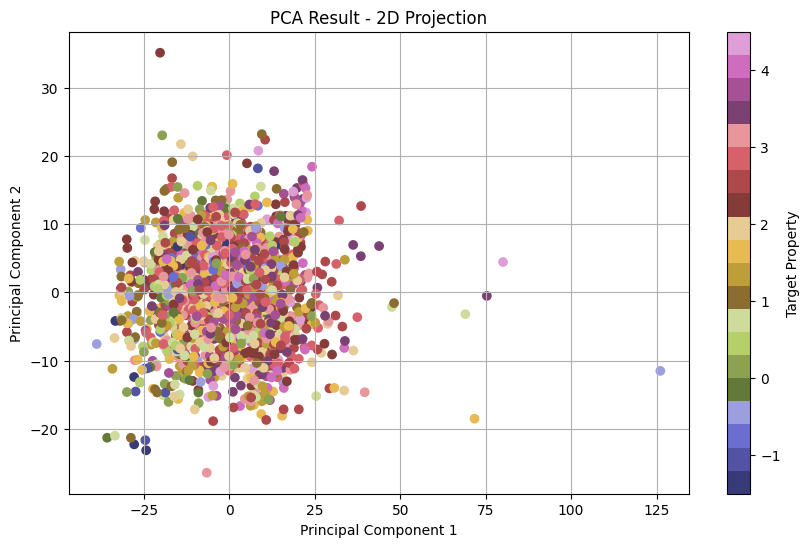

In [ ]:
X = dataset_cleaned.drop(columns=['experimental_proprty'])  # Features
y = dataset_cleaned['experimental_proprty']  # Target (optional for color coding)

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=y, cmap='tab20b')  # Color by target variable
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result - 2D Projection')
plt.colorbar(label='Target Property')  # Color bar to indicate target values
plt.grid(True)

plt.show()

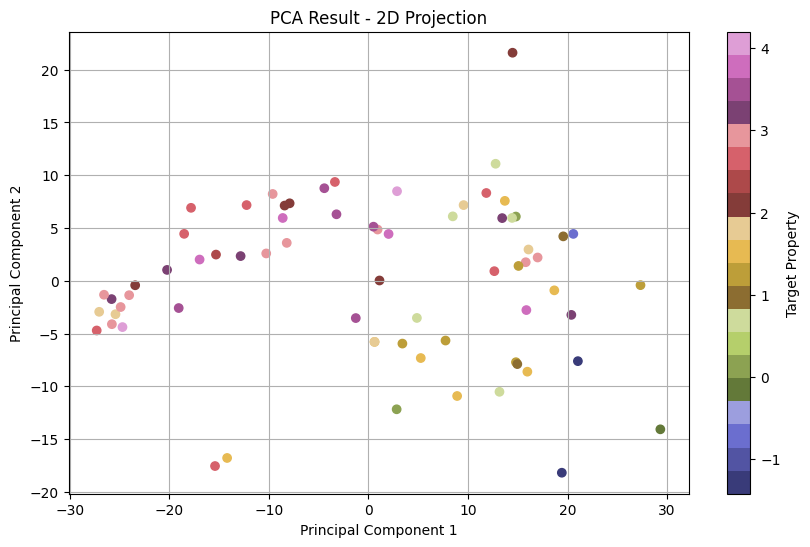

In [ ]:
X = dataset_filtered.drop(columns=['experimental_proprty'])  # Features
y = dataset_filtered['experimental_proprty']  # Target (optional for color coding)

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=y, cmap='tab20b')  # Color by target variable
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result - 2D Projection')
plt.colorbar(label='Target Property')  # Color bar to indicate target value
plt.grid(True)

plt.show()

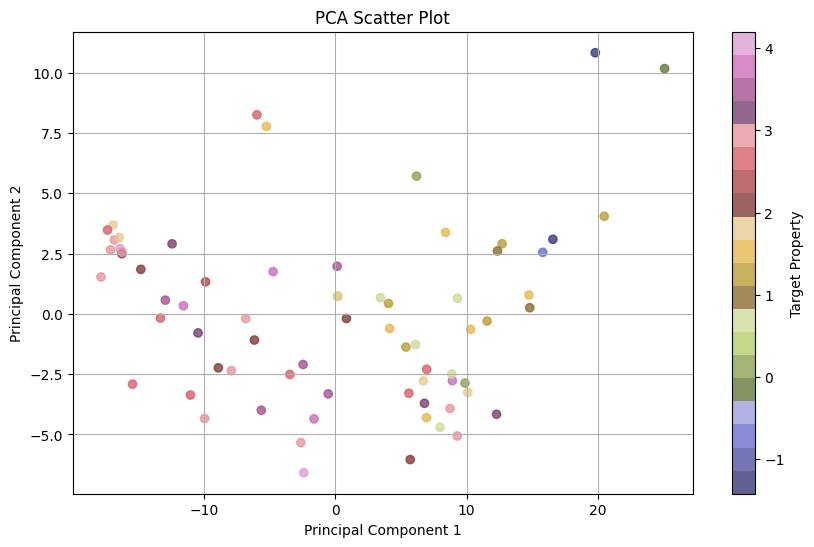

In [100]:
X = pd.DataFrame(dataset_filtered, columns=correlated_columns)
y = dataset_filtered['experimental_proprty']  # Target (for color coding)

# Standardize the data
X_scaled = StandardScaler().fit_transform(X)

# Perform PCA, reduce to 2 components for 2D plotting
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Plot PCA scatter plot
plt.figure(figsize=(10, 6))
sc = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=y, cmap='tab20b', alpha=0.8)
plt.title('PCA Scatter Plot')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(sc, label='Target Property')  # Add color bar for target variable
plt.grid(True)

plt.show()

**Bonus Question.:**

* Use any non-linear dimensionality reduction method. Plot data in 2D and color
code by the target property.

### Handling imports

In [83]:
%pip install umap-learn

In [85]:
from sklearn.manifold import TSNE
import umap

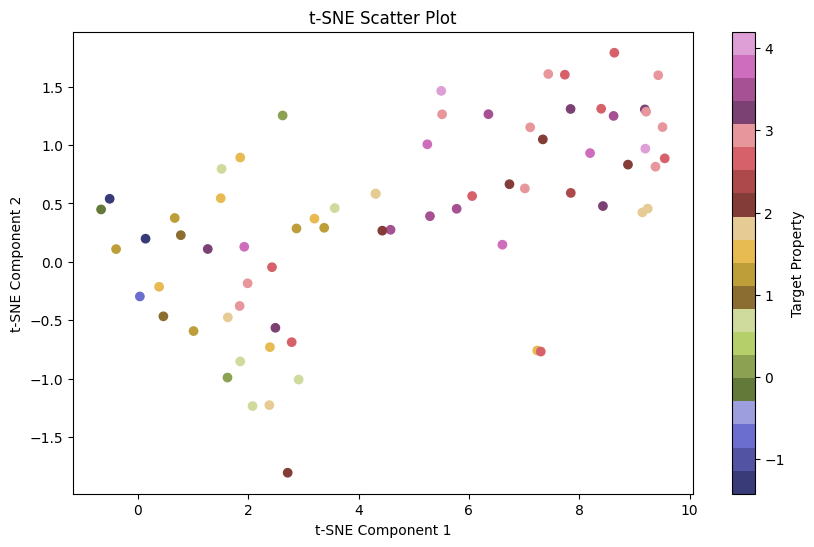

In [79]:
X = pd.DataFrame(dataset_filtered, columns=correlated_columns)
y = dataset_filtered['experimental_proprty']  # Target (for color coding)

X_scaled = StandardScaler().fit_transform(X)
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(10, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab20b')
plt.colorbar(sc, label='Target Property')
plt.title('t-SNE Scatter Plot')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


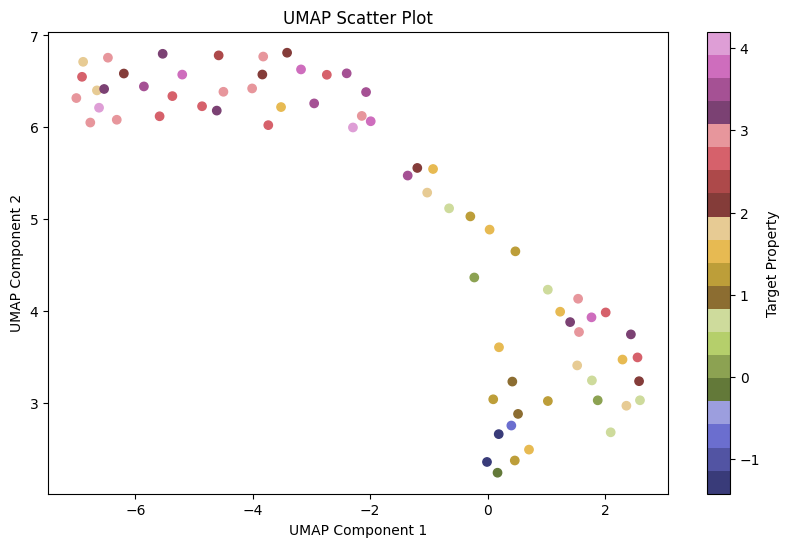

In [86]:
X = pd.DataFrame(dataset_filtered, columns=correlated_columns)
y = dataset_filtered['experimental_proprty']  # Target (for color coding)

X_scaled = StandardScaler().fit_transform(X)
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(10, 6))
sc = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab20b')
plt.colorbar(sc, label='Target Property')
plt.title('UMAP Scatter Plot')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()